Let's see a couple of examples of generalized linear models in action

In [1]:
%matplotlib inline

import io
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats
import scipy.special
import seaborn as sns
sns.set_style('white')
sns.set_context('notebook')




As an example of simple logistic regression, Suzuki et al. (2006) measured sand grain size on  28  beaches in Japan and observed the presence or absence of the burrowing wolf spider Lycosa ishikariana on each beach. Sand grain size is a measurement variable, and spider presence or absence is a nominal variable. Spider presence or absence is the dependent variable; if there is a relationship between the two variables, it would be sand grain size affecting spiders, not the presence of spiders affecting the sand.



In [2]:
data = """Grain	Spiders
0.245	absent
0.247	absent
0.285	present
0.299	present
0.327	present
0.347	present
0.356	absent
0.36	present
0.363	absent
0.364	present
0.398	absent
0.4	present
0.409	absent
0.421	present
0.432	absent
0.473	present
0.509	present
0.529	present
0.561	absent
0.569	absent
0.594	present
0.638	present
0.656	present
0.816	present
0.853	present
0.938	present
1.036	present
1.045	present
"""
df = pd.read_table(io.StringIO(data))
df.Spiders = df.Spiders == 'present'
df.head()



,Grain,Spiders
0,0.245,False
1,0.247,False
2,0.285,True
3,0.299,True
4,0.327,True


Let's plot the data

Text(0.5, 0, 'Grain size (in mm)')

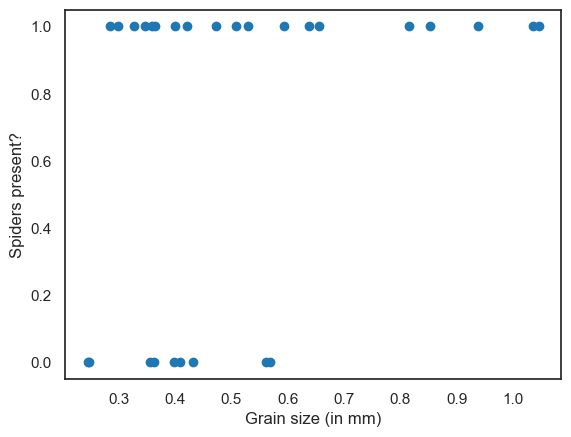

In [3]:

plt.plot(df.Grain,df.Spiders,'o')
plt.ylabel('Spiders present?')
plt.xlabel('Grain size (in mm)')


Inference

In [4]:
# We use statsmodel.api
# notice that I need to add the intercept manually
# It's really cumbersome, it's the way is it...
import statsmodels.api as sm

df['intercept'] = 1
log_reg = sm.Logit(df['Spiders'],df[['Grain','intercept']]).fit()




Optimization terminated successfully.
         Current function value: 0.546992
         Iterations 7


let's have a look at the summary

In [6]:
print(log_reg.summary())

                           Logit Regression Results                           
Dep. Variable:                Spiders   No. Observations:                   28
Model:                          Logit   Df Residuals:                       26
Method:                           MLE   Df Model:                            1
Date:                Thu, 26 Jan 2023   Pseudo R-squ.:                  0.1289
Time:                        12:08:43   Log-Likelihood:                -15.316
converged:                       True   LL-Null:                       -17.582
Covariance Type:            nonrobust   LLR p-value:                   0.03324
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Grain          5.1216      3.006      1.704      0.088      -0.770      11.014
intercept     -1.6476      1.354     -1.217      0.224      -4.302       1.007


Let's see the predictions on the data, the confusion matrix, and the accuracy. Finally, let's plot the resulting probability

Confusion Matrix : 
 [[ 2  7]
 [ 2 17]]
Test accuracy =  0.6785714285714286


Text(0.5, 0, 'Grain size (in mm)')

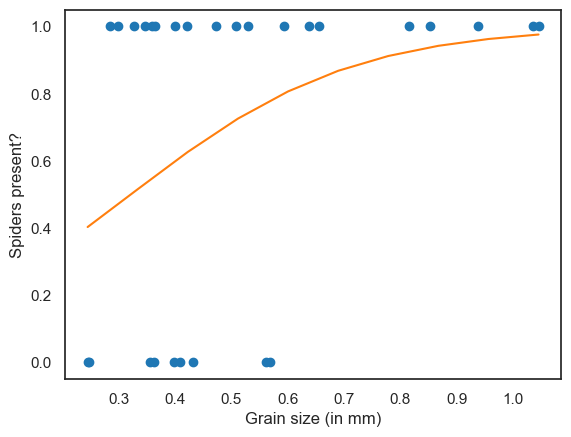

In [5]:
from sklearn.metrics import (confusion_matrix, accuracy_score)

# performing predictions on the test dataset
yhat = log_reg.predict(df[['Grain','intercept']])
prediction = list(map(round, yhat))

# confusion matrix
cm = confusion_matrix(df['Spiders'], prediction) 
print ("Confusion Matrix : \n", cm) 

# accuracy score of the model
print('Test accuracy = ', accuracy_score(df['Spiders'], prediction))

# Let's plot the data along with the probability of a spider being present
import numpy as np

m1=min(df.Grain)
m2=max(df.Grain)
HOW_MANY = 10
x = np.linspace(m1,m2,HOW_MANY)
inter = np.full(HOW_MANY, 1)
xpred=np.c_[x,inter]
yhat = log_reg.predict(xpred)

plt.plot(df.Grain,df.Spiders,'o')
plt.plot(x,yhat)
plt.ylabel('Spiders present?')
plt.xlabel('Grain size (in mm)')



Let's now see the probit model

In [6]:
prob_reg = sm.Probit(df['Spiders'],df[['Grain','intercept']]).fit()
print(prob_reg.summary())

# performing predictions on the test dataset
yhat = prob_reg.predict(df[['Grain','intercept']])
predictionp = list(map(round, yhat))

# confusion matrix
cm = confusion_matrix(df['Spiders'], predictionp) 
print ("Confusion Matrix : \n", cm) 

# accuracy score of the model
print('Test accuracy = ', accuracy_score(df['Spiders'], predictionp))



Optimization terminated successfully.
         Current function value: 0.544224
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:                Spiders   No. Observations:                   28
Model:                         Probit   Df Residuals:                       26
Method:                           MLE   Df Model:                            1
Date:                Wed, 01 Feb 2023   Pseudo R-squ.:                  0.1333
Time:                        07:01:41   Log-Likelihood:                -15.238
converged:                       True   LL-Null:                       -17.582
Covariance Type:            nonrobust   LLR p-value:                   0.03037
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Grain          3.1163      1.751      1.780      0.075      -0.316       6.549
intercept     -1.0046      0.

The same analysis can be performed with the more general function GLM in the statsmodel package in Phyton. Here you can specify the family and the link, it's similar to the glm command in R. 

In [15]:
reg2 = sm.GLM(df['Spiders'],df[['Grain','intercept']], family=sm.families.Binomial()).fit()
print(reg2.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                Spiders   No. Observations:                   28
Model:                            GLM   Df Residuals:                       26
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15.316
Date:                Thu, 26 Jan 2023   Deviance:                       30.632
Time:                        12:12:32   Pearson chi2:                     24.7
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1495
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Grain          5.1216      3.006      1.704      0.0

In [10]:
reg2 = sm.GLM(df['Spiders'],df[['Grain','intercept']], family=sm.families.Binomial()).fit()
print(reg2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Spiders   No. Observations:                   28
Model:                            GLM   Df Residuals:                       26
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15.316
Date:                Thu, 26 Jan 2023   Deviance:                       30.632
Time:                        12:10:44   Pearson chi2:                     24.7
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1495
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Grain          5.1216      3.006      1.704      0.0

In [11]:
# here we explicitly say we use the logit link
reg2 = sm.GLM(df['Spiders'],df[['Grain','intercept']], family=sm.families.Binomial(link=sm.families.links.logit())).fit()
print(reg2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Spiders   No. Observations:                   28
Model:                            GLM   Df Residuals:                       26
Model Family:                Binomial   Df Model:                            1
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15.316
Date:                Thu, 26 Jan 2023   Deviance:                       30.632
Time:                        12:10:47   Pearson chi2:                     24.7
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1495
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Grain          5.1216      3.006      1.704      0.0

In [7]:
# manual probit
reg2 = sm.GLM(df['Spiders'],df[['Grain','intercept']], family=sm.families.Binomial(link=sm.families.links.CDFLink())).fit()
print(reg2.summary())




                 Generalized Linear Model Regression Results                  
Dep. Variable:                Spiders   No. Observations:                   28
Model:                            GLM   Df Residuals:                       26
Model Family:                Binomial   Df Model:                            1
Link Function:                CDFLink   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15.238
Date:                Wed, 01 Feb 2023   Deviance:                       30.477
Time:                        07:01:53   Pearson chi2:                     24.5
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1542
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Grain          3.1163      1.684      1.851      0.0